In [1]:
import numpy as np
import scipy.io
import matplotlib.pyplot as plt
from skimage import img_as_float

# Load data
data = scipy.io.loadmat("facedata.mat")
faces = data['facedata']

faces.shape

(40, 10)

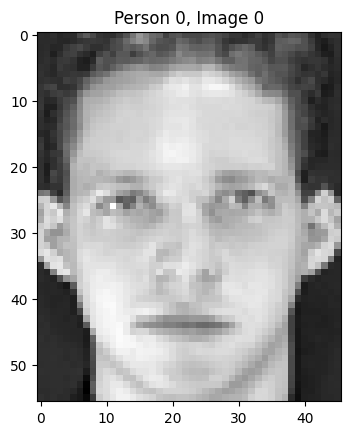

(56, 46)

In [2]:
plt.imshow(faces[0,0], cmap='gray')
plt.title("Person 0, Image 0")
plt.show()

faces[0,0].shape

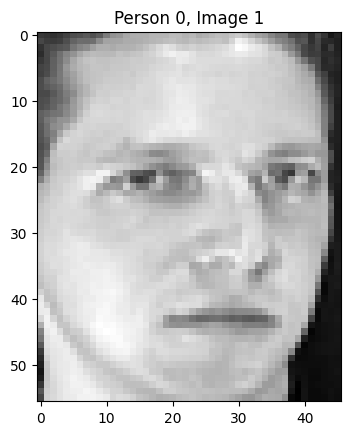

(56, 46)

In [3]:
plt.imshow(faces[0,1], cmap='gray')
plt.title("Person 0, Image 1")
plt.show()

faces[0,0].shape

In [4]:
def image_to_vector(img):
    img_f = img_as_float(img)
    return img_f.flatten()

In [5]:
T = []
T_labels = []
D = []
D_labels = []

for person in range(40):
    # training
    for img_idx in range(3):
        vec = image_to_vector(faces[person, img_idx])
        T.append(vec)
        T_labels.append(person)

    # test
    for img_idx in range(3, 10):
        vec = image_to_vector(faces[person, img_idx])
        D.append(vec)
        D_labels.append(person)

T = np.array(T)
D = np.array(D)
T_labels = np.array(T_labels)
D_labels = np.array(D_labels)

T.shape, D.shape

((120, 2576), (280, 2576))

In [6]:
def euclidean_distance(x, y):
    return np.linalg.norm(x - y)

In [7]:
from skimage import img_as_float
import numpy as np

xf = np.empty_like(faces, dtype=object)

for i in range(faces.shape[0]):        # people
    for j in range(faces.shape[1]):    # images per person
        xf[i, j] = img_as_float(faces[i, j])

In [8]:
def img_dist(imgA, imgB):
    a = imgA.flatten()
    b = imgB.flatten()
    return np.linalg.norm(a - b)

In [9]:
d_same_person = img_dist(xf[0,0], xf[0,1])
d_diff_person = img_dist(xf[0,0], xf[1,0])

print("Distance xf[0,0] vs xf[0,1] (same person):", d_same_person)
print("Distance xf[0,0] vs xf[1,0] (different person):", d_diff_person)

Distance xf[0,0] vs xf[0,1] (same person): 10.037616294165492
Distance xf[0,0] vs xf[1,0] (different person): 8.17329509973728


In [10]:
def compute_similarity_matrix(T, D):
    S = np.zeros((len(D), len(T)))
    for i in range(len(D)):
        for j in range(len(T)):
            S[i,j] = euclidean_distance(D[i], T[j])
    return S

S = compute_similarity_matrix(T, D)
S.shape

(280, 120)

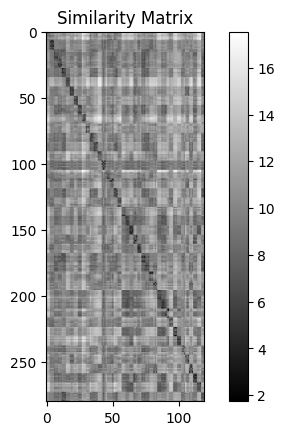

In [11]:
plt.imshow(S, cmap='gray')
plt.colorbar()
plt.title("Similarity Matrix")
plt.show()

In [12]:
def evaluate_threshold(S, T_labels, D_labels, threshold):
    TP = FP = TN = FN = 0
    
    for i in range(len(D)):
        min_idx = np.argmin(S[i])
        predicted_person = T_labels[min_idx]
        true_person = D_labels[i]
        
        if S[i,min_idx] < threshold:
            if predicted_person == true_person:
                TP += 1
            else:
                FP += 1
        else:
            if predicted_person == true_person:
                FN += 1
            else:
                TN += 1
    
    TPR = TP / (TP + FN)
    FPR = FP / (FP + TN)
    
    return TPR, FPR

In [13]:
tpr, fpr = evaluate_threshold(S, T_labels, D_labels, threshold=10)
print("TPR:", tpr)
print("FPR:", fpr)

TPR: 1.0
FPR: 1.0


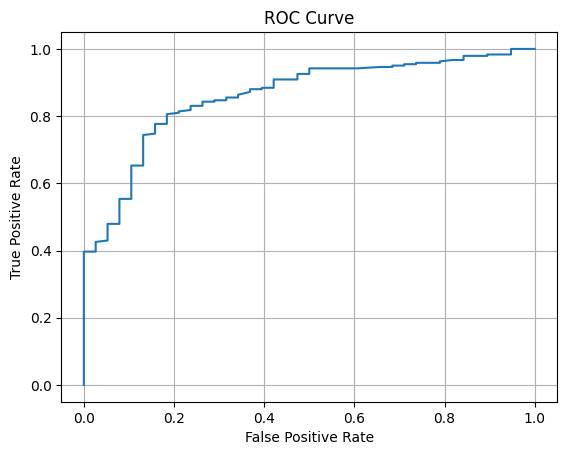

In [14]:
def compute_roc(S, T_labels, D_labels):
    dmins = np.min(S, axis=1)

    t_min = np.min(dmins) - 1e-6
    t_max = np.max(dmins) + 1e-6

    thresholds = np.linspace(t_min, t_max, 1000)

    TPRs = []
    FPRs = []

    for t in thresholds:
        tpr, fpr = evaluate_threshold(S, T_labels, D_labels, t)
        TPRs.append(tpr)
        FPRs.append(fpr)

    return np.array(FPRs), np.array(TPRs), thresholds

FPRs, TPRs, thresholds = compute_roc(S, T_labels, D_labels)

plt.plot(FPRs, TPRs)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.grid()
plt.show()

In [15]:
def compute_eer(FPRs, TPRs, thresholds):
    fnrs = 1 - TPRs
    idx = np.argmin(np.abs(FPRs - fnrs))
    eer = (FPRs[idx] + fnrs[idx]) / 2
    return eer, thresholds[idx], FPRs[idx], TPRs[idx]

eer, eer_t, eer_fpr, eer_tpr = compute_eer(FPRs, TPRs, thresholds)
print(f"EER ≈ {eer:.6f} at threshold {eer_t:.4f}")
print(f"At EER point: FPR={eer_fpr:.6f}, TPR={eer_tpr:.6f}, FNR={1-eer_tpr:.6f}")

EER ≈ 0.189213 at threshold 6.5479
At EER point: FPR=0.184211, TPR=0.805785, FNR=0.194215


In [16]:
def recall_at_fpr(FPRs, TPRs, thresholds, target_fpr=0.001):
    valid = np.where(FPRs <= target_fpr)[0]
    if len(valid) == 0:
        # no threshold achieves that low FPR
        idx = np.argmin(np.abs(FPRs - target_fpr))
        return TPRs[idx], thresholds[idx], FPRs[idx], False
    
    # among valid ones, choose the highest recall (TPR)
    best_idx = valid[np.argmax(TPRs[valid])]
    return TPRs[best_idx], thresholds[best_idx], FPRs[best_idx], True

recall, t_at, fpr_at, feasible = recall_at_fpr(FPRs, TPRs, thresholds, target_fpr=0.001)
print("Target FPR = 0.001 (0.1%)")
print(f"Recall (TPR) ≈ {recall:.6f}")
print(f"Threshold ≈ {t_at:.4f}")
print(f"Achieved FPR ≈ {fpr_at:.6f}")
print("Feasible (had some points with FPR <= 0.001)?", feasible)

Target FPR = 0.001 (0.1%)
Recall (TPR) ≈ 0.396694
Threshold ≈ 5.1569
Achieved FPR ≈ 0.000000
Feasible (had some points with FPR <= 0.001)? True


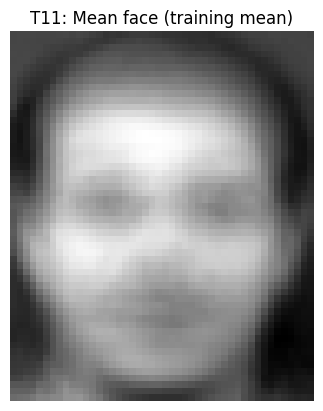

(2576,)

In [17]:
# T has shape (120, 2576)
mu = T.mean(axis=0)                  # (2576,)
mean_face = mu.reshape(56, 46)

plt.imshow(mean_face, cmap='gray')
plt.title("T11: Mean face (training mean)")
plt.axis('off')
plt.show()

mu.shape

In [18]:
Xhat = T - mu   # (120, 2576)
Xhat.shape

(120, 2576)

In [19]:
N, D = Xhat.shape
print("N =", N, "D =", D)
print("Covariance size:", (D, D))
print("Max possible rank (centered):", min(D, N-1))

N = 120 D = 2576
Covariance size: (2576, 2576)
Max possible rank (centered): 119


In [20]:
print("Gram size:", (N, N))
print("Max possible rank (centered):", min(N, D, N-1))

Gram size: (120, 120)
Max possible rank (centered): 119


In [21]:
# sanity check (small numeric tolerance)
G = Xhat @ Xhat.T
print("Is G symmetric?", np.allclose(G, G.T, atol=1e-8))

Is G symmetric? True


In [22]:
# eigen-decomposition of symmetric matrix
eigvals, eigvecs = np.linalg.eigh(G)   # eigvals ascending

# sort descending
idx = np.argsort(eigvals)[::-1]
eigvals = eigvals[idx]
eigvecs = eigvecs[:, idx]

# how many non-zero eigenvalues? (treat tiny as 0)
tol = 1e-8
num_nonzero = np.sum(eigvals > tol)
print("T15: num non-zero eigenvalues:", num_nonzero)
print("Top 10 eigenvalues:", eigvals[:10])
print("Smallest 10 eigenvalues:", eigvals[-10:])

T15: num non-zero eigenvalues: 119
Top 10 eigenvalues: [1423.92971484  875.37517697  558.62440028  407.34715673  371.02127373
  263.28080075  203.39698967  190.96510133  166.54805607  143.5705511 ]
Smallest 10 eigenvalues: [3.17991974e+00 3.13382008e+00 3.07484004e+00 2.73615457e+00
 2.57040486e+00 2.55027268e+00 2.09754295e+00 1.69989241e+00
 1.09424775e+00 5.50001933e-14]


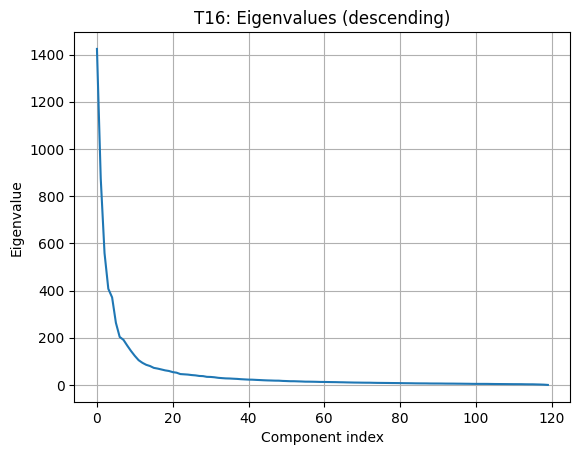

T16: number of eigenvectors to keep 95% variance: 64


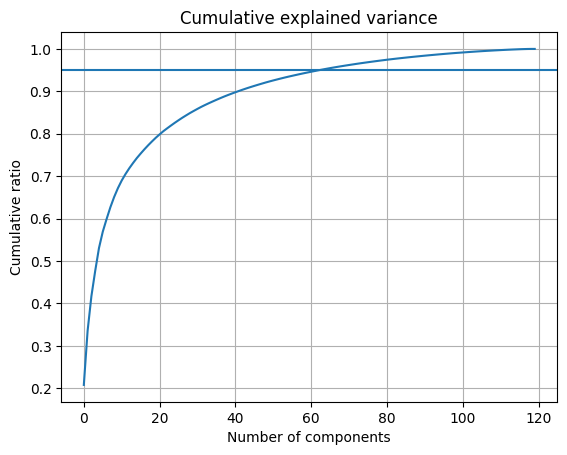

In [23]:
# keep only positive eigenvalues (avoid tiny negatives from numerical error)
eigvals_pos = np.maximum(eigvals, 0)

explained = eigvals_pos / np.sum(eigvals_pos)
cum_explained = np.cumsum(explained)

plt.figure()
plt.plot(eigvals_pos)
plt.title("T16: Eigenvalues (descending)")
plt.xlabel("Component index")
plt.ylabel("Eigenvalue")
plt.grid(True)
plt.show()

# PCs needed for 95% variance
k95 = np.searchsorted(cum_explained, 0.95) + 1
print("T16: number of eigenvectors to keep 95% variance:", k95)

plt.figure()
plt.plot(cum_explained)
plt.axhline(0.95)
plt.title("Cumulative explained variance")
plt.xlabel("Number of components")
plt.ylabel("Cumulative ratio")
plt.grid(True)
plt.show()

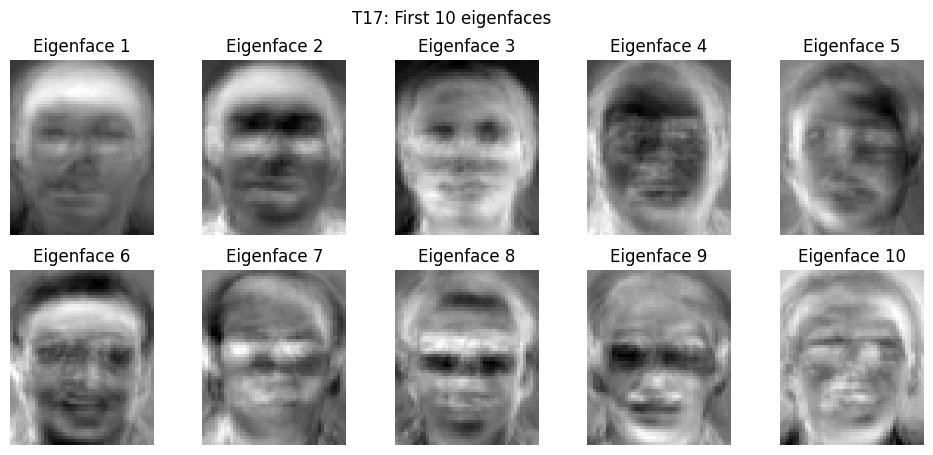

In [24]:
def compute_eigenfaces(Xhat, gram_eigvecs, num=10):
    """
    Xhat: (N,D)
    gram_eigvecs: (N,N) columns are eigenvectors of G
    returns eigenfaces: (num, D)
    """
    eigenfaces = []
    for i in range(num):
        v_tilde = gram_eigvecs[:, i]          # (N,)
        v = Xhat.T @ v_tilde                  # (D,)
        v = v / (np.linalg.norm(v) + 1e-12)   # normalize to norm 1
        eigenfaces.append(v)
    return np.array(eigenfaces)

eigenfaces10 = compute_eigenfaces(Xhat, eigvecs, num=10)  # (10, 2576)

# Plot first 10 eigenfaces
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.ravel()):
    ax.imshow(eigenfaces10[i].reshape(56,46), cmap='gray')
    ax.set_title(f"Eigenface {i+1}")
    ax.axis('off')
plt.suptitle("T17: First 10 eigenfaces")
plt.show()

In [25]:
T = []
T_labels = []
D = []
D_labels = []

for person in range(40):
    # training
    for img_idx in range(3):
        vec = image_to_vector(faces[person, img_idx])
        T.append(vec)
        T_labels.append(person)

    # test
    for img_idx in range(3, 10):
        vec = image_to_vector(faces[person, img_idx])
        D.append(vec)
        D_labels.append(person)

T = np.array(T)
D = np.array(D)
T_labels = np.array(T_labels)
D_labels = np.array(D_labels)

print("T shape:", T.shape)
print("D shape:", D.shape)

T shape: (120, 2576)
D shape: (280, 2576)


In [26]:
def compute_eigenfaces_matrix(Xhat, gram_eigvecs, k):
    """
    Returns V: (D,k) eigenfaces as columns, each normalized to unit norm.
    Xhat: (N,D)
    gram_eigvecs: (N,N) columns are eigenvectors of G=Xhat Xhat^T (sorted descending)
    """
    N, D = Xhat.shape
    V = np.zeros((D, k))
    for i in range(k):
        v_tilde = gram_eigvecs[:, i]      # (N,)
        v = Xhat.T @ v_tilde              # (D,)
        v = v / (np.linalg.norm(v) + 1e-12)
        V[:, i] = v
    return V

# example: k=10
k = 10
V10 = compute_eigenfaces_matrix(Xhat, eigvecs, k)
V10.shape

(2576, 10)

In [27]:
def project_features(X, mu, V):
    """
    X: (M,D)
    mu: (D,)
    V: (D,k)
    returns P: (M,k)
    """
    return (X - mu) @ V   # (M,k)

T_p10 = project_features(T, mu, V10)   # (120,10)
D_p10 = project_features(D, mu, V10)   # (280,10)

T_p10.shape, D_p10.shape

((120, 10), (280, 10))

In [28]:
def compute_similarity_matrix_fast(T_feat, D_feat):
    """
    Efficient pairwise Euclidean distance matrix between D_feat (M,k) and T_feat (N,k).
    Returns S: (M,N) where S[i,j]=||D_i - T_j||
    """
    # ||a-b||^2 = ||a||^2 + ||b||^2 - 2a.b
    A2 = np.sum(D_feat**2, axis=1, keepdims=True)      # (M,1)
    B2 = np.sum(T_feat**2, axis=1, keepdims=True).T    # (1,N)
    sq = A2 + B2 - 2 * (D_feat @ T_feat.T)
    sq = np.maximum(sq, 0)
    return np.sqrt(sq)

S10 = compute_similarity_matrix_fast(T_p10, D_p10)  # (280,120)
S10.shape

(280, 120)

In [29]:
def evaluate_threshold_from_S(S, T_labels, D_labels, threshold):
    TP = FP = TN = FN = 0
    
    for i in range(S.shape[0]):  # for each test image
        min_idx = np.argmin(S[i])
        predicted_person = T_labels[min_idx]
        true_person = D_labels[i]
        
        accept = (S[i, min_idx] < threshold)
        
        if accept:
            if predicted_person == true_person:
                TP += 1
            else:
                FP += 1
        else:
            if predicted_person == true_person:
                FN += 1
            else:
                TN += 1
    
    TPR = TP / (TP + FN + 1e-12)
    FPR = FP / (FP + TN + 1e-12)
    return TPR, FPR

def compute_roc_from_S(S, T_labels, D_labels, num_thresh=1000):
    thresholds = np.linspace(np.min(S), np.max(S), num_thresh)
    TPRs = np.zeros(num_thresh)
    FPRs = np.zeros(num_thresh)
    for i, t in enumerate(thresholds):
        TPRs[i], FPRs[i] = evaluate_threshold_from_S(S, T_labels, D_labels, t)
    return FPRs, TPRs, thresholds

def compute_eer(FPRs, TPRs, thresholds):
    fnrs = 1 - TPRs
    idx = np.argmin(np.abs(FPRs - fnrs))
    eer = (FPRs[idx] + fnrs[idx]) / 2
    return eer, thresholds[idx], FPRs[idx], TPRs[idx]

def recall_at_fpr(FPRs, TPRs, thresholds, target_fpr=0.001):
    valid = np.where(FPRs <= target_fpr)[0]
    if len(valid) == 0:
        idx = np.argmin(np.abs(FPRs - target_fpr))
        return TPRs[idx], thresholds[idx], FPRs[idx], False
    best_idx = valid[np.argmax(TPRs[valid])]
    return TPRs[best_idx], thresholds[best_idx], FPRs[best_idx], True

T19 (k=10):
  EER ≈ 0.248770 at threshold 2.7848
  Recall at 0.1% FAR (FPR=0.001): 0.444976
  Achieved FPR ≈ 0.000000 at threshold 1.9603, feasible=True


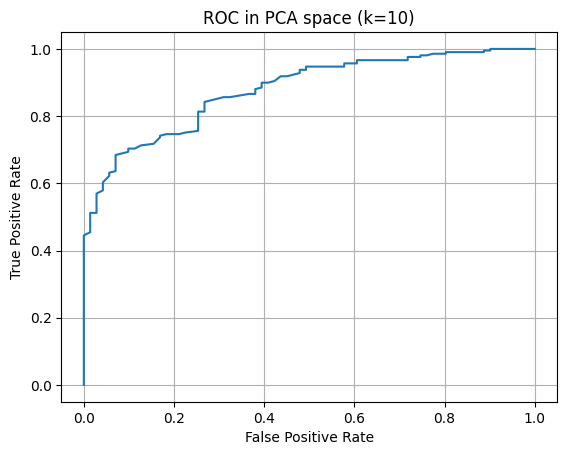

In [30]:
FPRs10, TPRs10, thr10 = compute_roc_from_S(S10, T_labels, D_labels, num_thresh=1000)

eer10, eer_t10, fpr_eer10, tpr_eer10 = compute_eer(FPRs10, TPRs10, thr10)
recall10, t_at10, fpr_at10, feasible10 = recall_at_fpr(FPRs10, TPRs10, thr10, target_fpr=0.001)

print("T19 (k=10):")
print(f"  EER ≈ {eer10:.6f} at threshold {eer_t10:.4f}")
print(f"  Recall at 0.1% FAR (FPR=0.001): {recall10:.6f}")
print(f"  Achieved FPR ≈ {fpr_at10:.6f} at threshold {t_at10:.4f}, feasible={feasible10}")

plt.plot(FPRs10, TPRs10)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC in PCA space (k=10)")
plt.grid(True)
plt.show()

In [31]:
results = []

for k in range(5, 15):
    V = compute_eigenfaces_matrix(Xhat, eigvecs, k)
    T_p = project_features(T, mu, V)
    D_p = project_features(D, mu, V)
    S = compute_similarity_matrix_fast(T_p, D_p)
    
    FPRs, TPRs, thr = compute_roc_from_S(S, T_labels, D_labels, num_thresh=1000)
    eer, eer_t, _, _ = compute_eer(FPRs, TPRs, thr)
    recall, _, fpr_at, feasible = recall_at_fpr(FPRs, TPRs, thr, target_fpr=0.001)
    
    results.append((k, eer, recall, fpr_at, feasible))

# print nicely
for k, eer, rec, fpr_at, feas in results:
    print(f"k={k:2d} | EER={eer:.6f} | Recall@0.1%FAR={rec:.6f} | achievedFPR={fpr_at:.6f} | feasible={feas}")

best = min(results, key=lambda x: x[1])
print("\nT20 best k by EER:", best[0], "with EER =", best[1])

k= 5 | EER=0.350060 | Recall@0.1%FAR=0.085890 | achievedFPR=0.000000 | feasible=True
k= 6 | EER=0.275510 | Recall@0.1%FAR=0.098901 | achievedFPR=0.000000 | feasible=True
k= 7 | EER=0.269490 | Recall@0.1%FAR=0.373057 | achievedFPR=0.000000 | feasible=True
k= 8 | EER=0.221227 | Recall@0.1%FAR=0.458128 | achievedFPR=0.000000 | feasible=True
k= 9 | EER=0.235572 | Recall@0.1%FAR=0.410377 | achievedFPR=0.000000 | feasible=True
k=10 | EER=0.248770 | Recall@0.1%FAR=0.444976 | achievedFPR=0.000000 | feasible=True
k=11 | EER=0.216995 | Recall@0.1%FAR=0.479070 | achievedFPR=0.000000 | feasible=True
k=12 | EER=0.221143 | Recall@0.1%FAR=0.500000 | achievedFPR=0.000000 | feasible=True
k=13 | EER=0.195238 | Recall@0.1%FAR=0.442857 | achievedFPR=0.000000 | feasible=True
k=14 | EER=0.224616 | Recall@0.1%FAR=0.488263 | achievedFPR=0.000000 | feasible=True

T20 best k by EER: 13 with EER = 0.19523809523809577


In [35]:
k_pca = 80  # key fix: <= N - C

V_pca = compute_eigenfaces_matrix(Xhat, eigvecs, k_pca)
T_pca = project_features(T, mu, V_pca)
D_pca = project_features(D, mu, V_pca)

SB, SW = compute_scatter_matrices(T_pca, T_labels)

# Symmetrize (tiny numerical cleanup)
SB = (SB + SB.T) / 2
SW = (SW + SW.T) / 2

# Regularize SW to make it SPD
eps = 1e-6
SW_reg = SW + eps * np.eye(SW.shape[0])

from scipy.linalg import eigh
eigvals_lda, eigvecs_lda = eigh(SB, SW_reg)

# sort descending
idx = np.argsort(eigvals_lda)[::-1]
eigvals_lda = eigvals_lda[idx]
eigvecs_lda = eigvecs_lda[:, idx]

print("Top 10 LDA eigvals:", eigvals_lda[:10])
print("Non-zero eigvals (~):", np.sum(eigvals_lda > 1e-8))

Top 10 LDA eigvals: [2.34799393e+07 1.48046682e+04 4.33113535e+03 2.24450107e+03
 1.72333255e+03 1.16153009e+03 7.44144027e+02 5.15716069e+02
 3.79751801e+02 3.19820502e+02]
Non-zero eigvals (~): 40


In [36]:
def compute_scatter_matrices(X, labels):
    """
    X: (N,k)
    labels: (N,)
    """
    classes = np.unique(labels)
    k = X.shape[1]
    
    mu_global = np.mean(X, axis=0)
    
    SB = np.zeros((k, k))
    SW = np.zeros((k, k))
    
    for c in classes:
        Xc = X[labels == c]
        Nc = Xc.shape[0]
        mu_c = np.mean(Xc, axis=0)
        
        # between-class
        diff = (mu_c - mu_global).reshape(-1,1)
        SB += Nc * (diff @ diff.T)
        
        # within-class
        Xc_centered = Xc - mu_c
        SW += Xc_centered.T @ Xc_centered
        
    return SB, SW

SB, SW = compute_scatter_matrices(T_pca, T_labels)

In [37]:
from scipy.linalg import eigh

# Solve SB w = λ SW w
eigvals_lda, eigvecs_lda = eigh(SB, SW)

# sort descending
idx = np.argsort(eigvals_lda)[::-1]
eigvals_lda = eigvals_lda[idx]
eigvecs_lda = eigvecs_lda[:, idx]

# number of non-zero eigenvalues
print("Non-zero eigenvalues:",
      np.sum(np.real(eigvals_lda) > 1e-8))

Non-zero eigenvalues: 39


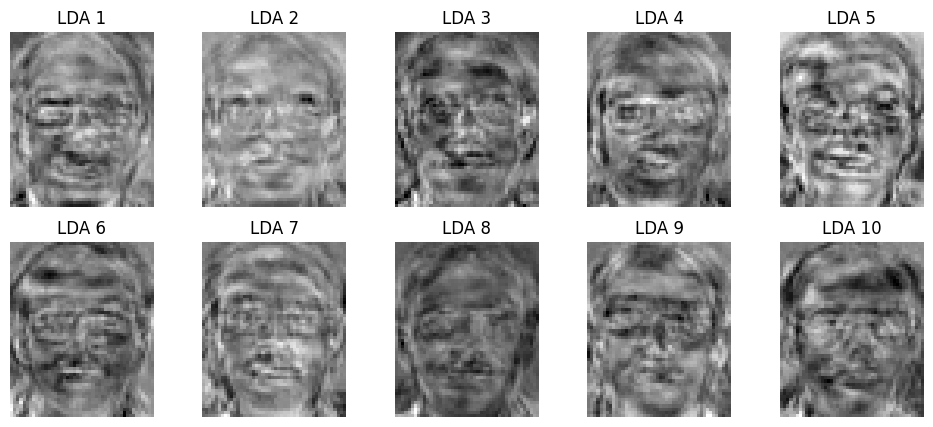

In [38]:
def compute_lda_images(V_pca, eigvecs_lda, num=10):
    lda_imgs = []
    for i in range(num):
        w_lda = np.real(eigvecs_lda[:, i])
        w_img = V_pca @ w_lda
        w_img = w_img / (np.linalg.norm(w_img) + 1e-12)
        lda_imgs.append(w_img)
    return np.array(lda_imgs)

lda_imgs = compute_lda_images(V_pca, eigvecs_lda, num=10)

# plot
fig, axes = plt.subplots(2,5, figsize=(12,5))
for i, ax in enumerate(axes.ravel()):
    ax.imshow(lda_imgs[i].reshape(56,46), cmap='gray')
    ax.set_title(f"LDA {i+1}")
    ax.axis('off')
plt.show()

In [40]:
def pairwise_euclidean(D_feat, T_feat):
    """
    Compute pairwise Euclidean distance matrix.
    
    Parameters:
        D_feat : (M, d)  test feature matrix
        T_feat : (N, d)  train feature matrix
        
    Returns:
        S : (M, N) matrix where
            S[i, j] = || D_feat[i] - T_feat[j] ||
    """
    D_feat = np.asarray(D_feat)
    T_feat = np.asarray(T_feat)

    # Ensure 2D
    if D_feat.ndim == 1:
        D_feat = D_feat.reshape(1, -1)
    if T_feat.ndim == 1:
        T_feat = T_feat.reshape(1, -1)

    # ||a-b||^2 = ||a||^2 + ||b||^2 - 2 a·b
    A2 = np.sum(D_feat**2, axis=1, keepdims=True)      # (M,1)
    B2 = np.sum(T_feat**2, axis=1, keepdims=True).T    # (1,N)

    sq = A2 + B2 - 2 * (D_feat @ T_feat.T)

    # Numerical stability
    sq = np.maximum(sq, 0)

    return np.sqrt(sq)

In [41]:
m = 39
W_lda = np.real(eigvecs_lda[:, :m])   # (100,39)

T_fisher = T_pca @ W_lda
D_fisher = D_pca @ W_lda

S_fisher = pairwise_euclidean(D_fisher, T_fisher)

In [42]:
FPRs_f, TPRs_f, thr_f = compute_roc_from_S(S_fisher, T_labels, D_labels)

eer_f, _, _, _ = compute_eer(FPRs_f, TPRs_f, thr_f)
recall_f, _, fpr_at_f, feasible_f = recall_at_fpr(FPRs_f, TPRs_f, thr_f, 0.001)

print("Fisherface EER:", eer_f)
print("Fisherface Recall@0.1%FAR:", recall_f)

Fisherface EER: 0.4772549019607938
Fisherface Recall@0.1%FAR: 0.19999999999999202


In [44]:
S_raw = pairwise_euclidean(D, T)   # D: (280,2576), T: (120,2576)
S_raw.shape

(280, 120)

In [45]:
FPRs_raw, TPRs_raw, thr_raw = compute_roc_from_S(
    S_raw, T_labels, D_labels, num_thresh=1000
)

eer_raw, _, _, _ = compute_eer(FPRs_raw, TPRs_raw, thr_raw)
recall_raw, _, fpr_at_raw, feasible_raw = recall_at_fpr(
    FPRs_raw, TPRs_raw, thr_raw, 0.001
)

print("RAW:")
print("  EER:", eer_raw)
print("  Recall@0.1%FAR:", recall_raw)

RAW:
  EER: 0.1892127011744229
  Recall@0.1%FAR: 0.3966942148760314


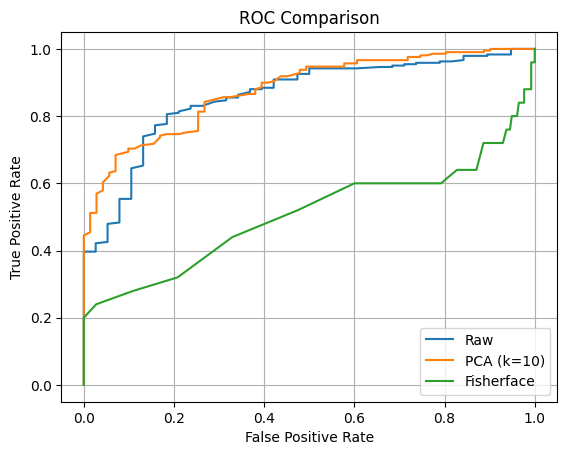

In [46]:
plt.plot(FPRs_raw, TPRs_raw, label="Raw")
plt.plot(FPRs10, TPRs10, label="PCA (k=10)")
plt.plot(FPRs_f, TPRs_f, label="Fisherface")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True)
plt.title("ROC Comparison")
plt.show()